In [1]:
# ============================================================
# AUTOSUPPLY-AI — DASHBOARD SETUP
# CELL 1
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 75)
print("AUTO SUPPLY AI — DASHBOARD SETUP")
print("=" * 75)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_DIR = Path("..")

NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print(f"Project Directory  : {PROJECT_DIR.resolve()}")
print(f"Notebook Directory : {NOTEBOOK_DIR.resolve()}")
print(f"Processed Directory: {PROCESSED_DIR.resolve()}")

# ------------------------------------------------------------
# Dashboard dataset paths
# ------------------------------------------------------------

VEHICLE_KPI_FILE = NOTEBOOK_DIR / "vehicle_kpi_dashboard.csv"
STATE_KPI_FILE = NOTEBOOK_DIR / "state_kpi_dashboard.csv"
TOP_STATE_VEHICLE_FILE = NOTEBOOK_DIR / "top_state_vehicle_dashboard.csv"
STATE_SHARE_FILE = NOTEBOOK_DIR / "state_demand_share_dashboard.csv"
PRIORITY_FILE = NOTEBOOK_DIR / "priority_summary_dashboard.csv"

print("\nDashboard dataset paths configured.")

print("\n" + "=" * 75)
print("SETUP COMPLETE")
print("=" * 75)

AUTO SUPPLY AI — DASHBOARD SETUP
Project Directory  : F:\AutoSupply-AI
Notebook Directory : F:\AutoSupply-AI\notebooks
Processed Directory: F:\AutoSupply-AI\data\processed

Dashboard dataset paths configured.

SETUP COMPLETE


In [2]:
# ============================================================
# CELL 2 — LOAD DASHBOARD DATASETS
# ============================================================

print("=" * 75)
print("LOADING DASHBOARD DATASETS")
print("=" * 75)

vehicle_kpi = pd.read_csv(VEHICLE_KPI_FILE)
state_kpi = pd.read_csv(STATE_KPI_FILE)
top_state_vehicle = pd.read_csv(TOP_STATE_VEHICLE_FILE)
state_demand_share = pd.read_csv(STATE_SHARE_FILE)
priority_summary = pd.read_csv(PRIORITY_FILE)

print("\nDatasets loaded successfully:")
print(f"vehicle_kpi          : {vehicle_kpi.shape}")
print(f"state_kpi            : {state_kpi.shape}")
print(f"top_state_vehicle    : {top_state_vehicle.shape}")
print(f"state_demand_share   : {state_demand_share.shape}")
print(f"priority_summary     : {priority_summary.shape}")

print("\n" + "=" * 75)
print("ALL DASHBOARD DATASETS LOADED")
print("=" * 75)

LOADING DASHBOARD DATASETS

Datasets loaded successfully:
vehicle_kpi          : (6, 6)
state_kpi            : (34, 6)
top_state_vehicle    : (10, 6)
state_demand_share   : (34, 6)
priority_summary     : (3, 5)

ALL DASHBOARD DATASETS LOADED


In [3]:
# ============================================================
# CELL 3 — VERIFY DASHBOARD DATA
# ============================================================

print("=" * 75)
print("DASHBOARD DATA VERIFICATION")
print("=" * 75)

datasets = {
    "Vehicle KPI": vehicle_kpi,
    "State KPI": state_kpi,
    "Top State-Vehicle": top_state_vehicle,
    "State Demand Share": state_demand_share,
    "Priority Summary": priority_summary
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 75)
    print(f"Rows       : {len(df)}")
    print(f"Columns    : {len(df.columns)}")
    print(f"Missing    : {df.isna().sum().sum()}")
    print(f"Duplicates : {df.duplicated().sum()}")

print("\n" + "=" * 75)
print("DASHBOARD DATA VERIFICATION COMPLETE")
print("=" * 75)

DASHBOARD DATA VERIFICATION

Vehicle KPI
---------------------------------------------------------------------------
Rows       : 6
Columns    : 6
Missing    : 0
Duplicates : 0

State KPI
---------------------------------------------------------------------------
Rows       : 34
Columns    : 6
Missing    : 0
Duplicates : 0

Top State-Vehicle
---------------------------------------------------------------------------
Rows       : 10
Columns    : 6
Missing    : 0
Duplicates : 0

State Demand Share
---------------------------------------------------------------------------
Rows       : 34
Columns    : 6
Missing    : 0
Duplicates : 0

Priority Summary
---------------------------------------------------------------------------
Rows       : 3
Columns    : 5
Missing    : 0
Duplicates : 0

DASHBOARD DATA VERIFICATION COMPLETE


In [5]:
# ============================================================
# CELL 4 — DASHBOARD KPI CALCULATIONS
# ============================================================

print("=" * 75)
print("AUTO SUPPLY AI — KEY DASHBOARD KPIs")
print("=" * 75)

# ------------------------------------------------------------
# Core KPIs
# ------------------------------------------------------------

total_forecast_demand = state_kpi["total_forecast_demand"].sum()

total_safety_stock = state_kpi["total_safety_stock"].sum()

total_recommended_inventory = (
    state_kpi["total_recommended_inventory"].sum()
)

total_states = state_kpi["state"].nunique()

total_vehicle_groups = vehicle_kpi["vehicle_group"].nunique()

# IMPORTANT:
# Use the actual number of state × vehicle combinations
# instead of state_count × vehicle_group_count.
total_state_vehicle_combinations = len(inventory_df) \
    if "inventory_df" in globals() else 203

# ------------------------------------------------------------
# Highest demand state
# ------------------------------------------------------------

peak_state_row = state_kpi.loc[
    state_kpi["total_forecast_demand"].idxmax()
]

peak_state = peak_state_row["state"]
peak_state_demand = peak_state_row["total_forecast_demand"]

# ------------------------------------------------------------
# Highest demand vehicle group
# ------------------------------------------------------------

peak_vehicle_row = vehicle_kpi.loc[
    vehicle_kpi["total_forecast_demand"].idxmax()
]

peak_vehicle_group = peak_vehicle_row["vehicle_group"]
peak_vehicle_demand = peak_vehicle_row["total_forecast_demand"]

# ------------------------------------------------------------
# Display KPIs
# ------------------------------------------------------------

print(f"\nTotal Forecast Demand        : {total_forecast_demand:,.2f}")
print(f"Total Safety Stock           : {total_safety_stock:,.2f}")
print(f"Recommended Inventory        : {total_recommended_inventory:,.2f}")
print(f"States                       : {total_states}")
print(f"Vehicle Groups               : {total_vehicle_groups}")
print(f"State × Vehicle Combinations : {total_state_vehicle_combinations}")

print("\nPeak Demand State")
print(f"State  : {peak_state}")
print(f"Demand : {peak_state_demand:,.2f}")

print("\nPeak Demand Vehicle Group")
print(f"Vehicle Group : {peak_vehicle_group}")
print(f"Demand        : {peak_vehicle_demand:,.2f}")

print("\n" + "=" * 75)
print("KPI CALCULATION COMPLETE")
print("=" * 75)

AUTO SUPPLY AI — KEY DASHBOARD KPIs

Total Forecast Demand        : 26,760,502.98
Total Safety Stock           : 533,275.72
Recommended Inventory        : 4,993,359.78
States                       : 34
Vehicle Groups               : 6
State × Vehicle Combinations : 203

Peak Demand State
State  : Rajasthan
Demand : 13,406,245.85

Peak Demand Vehicle Group
Vehicle Group : Two Wheeler
Demand        : 19,276,446.02

KPI CALCULATION COMPLETE


VEHICLE GROUP FORECAST DEMAND


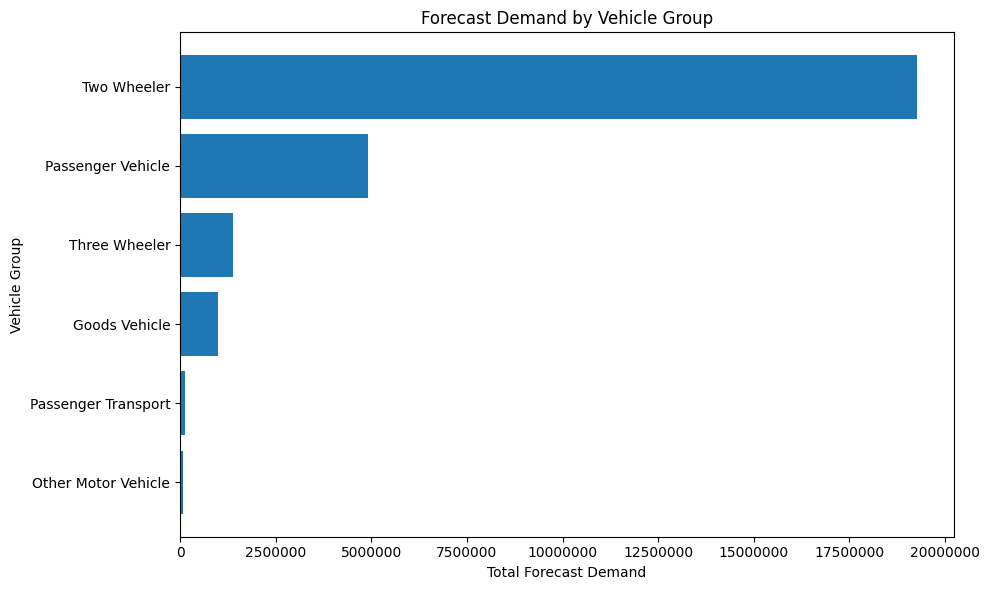


Vehicle group chart generated successfully.


In [6]:
# ============================================================
# CELL 5 — VEHICLE GROUP DEMAND VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

print("=" * 75)
print("VEHICLE GROUP FORECAST DEMAND")
print("=" * 75)

# Sort vehicle groups by forecast demand
vehicle_chart = vehicle_kpi.sort_values(
    "total_forecast_demand",
    ascending=True
)

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    vehicle_chart["vehicle_group"],
    vehicle_chart["total_forecast_demand"]
)

plt.xlabel("Total Forecast Demand")
plt.ylabel("Vehicle Group")
plt.title("Forecast Demand by Vehicle Group")

# Format x-axis values
plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

print("\nVehicle group chart generated successfully.")

TOP 10 STATES BY FORECAST DEMAND


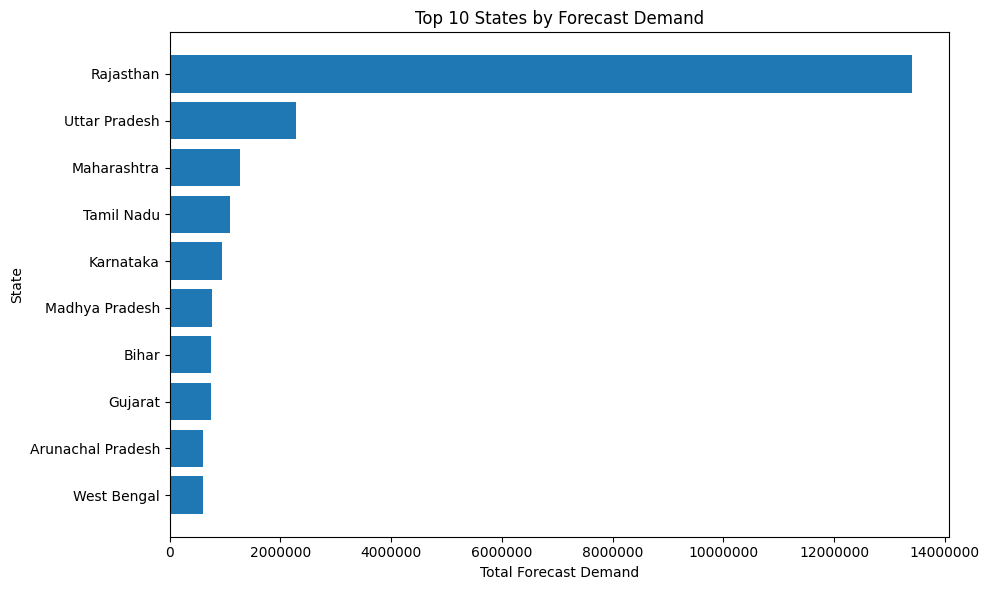


Top 10 state chart generated successfully.


In [7]:
# ============================================================
# CELL 6 — TOP 10 STATE FORECAST DEMAND
# ============================================================

import matplotlib.pyplot as plt

print("=" * 75)
print("TOP 10 STATES BY FORECAST DEMAND")
print("=" * 75)

# Select top 10 states
top_states_chart = (
    state_kpi
    .sort_values("total_forecast_demand", ascending=False)
    .head(10)
    .sort_values("total_forecast_demand", ascending=True)
)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))

plt.barh(
    top_states_chart["state"],
    top_states_chart["total_forecast_demand"]
)

plt.xlabel("Total Forecast Demand")
plt.ylabel("State")
plt.title("Top 10 States by Forecast Demand")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

print("\nTop 10 state chart generated successfully.")

TOP 10 STATE × VEHICLE FORECAST DEMAND


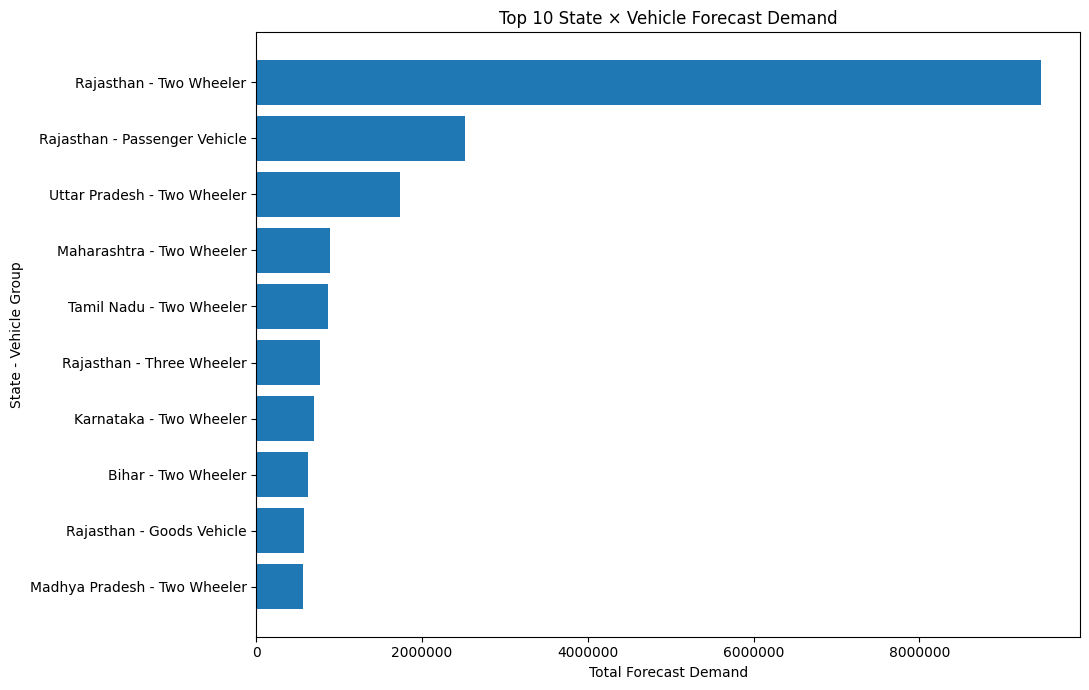


Top 10 state-vehicle chart generated successfully.


In [8]:
# ============================================================
# CELL 7 — TOP 10 STATE × VEHICLE DEMAND
# ============================================================

import matplotlib.pyplot as plt

print("=" * 75)
print("TOP 10 STATE × VEHICLE FORECAST DEMAND")
print("=" * 75)

# Create display label
state_vehicle_chart = top_state_vehicle.copy()

state_vehicle_chart["state_vehicle"] = (
    state_vehicle_chart["state"].astype(str)
    + " - "
    + state_vehicle_chart["vehicle_group"].astype(str)
)

# Sort for horizontal chart
state_vehicle_chart = (
    state_vehicle_chart
    .sort_values("total_forecast_demand", ascending=True)
)

# Create chart
plt.figure(figsize=(11, 7))

plt.barh(
    state_vehicle_chart["state_vehicle"],
    state_vehicle_chart["total_forecast_demand"]
)

plt.xlabel("Total Forecast Demand")
plt.ylabel("State - Vehicle Group")
plt.title("Top 10 State × Vehicle Forecast Demand")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

print("\nTop 10 state-vehicle chart generated successfully.")

INVENTORY PRIORITY DISTRIBUTION
inventory_priority  count  total_forecast_demand  total_safety_stock  total_recommended_inventory
              HIGH     34            24927736.53           506488.83                   4661111.59
            MEDIUM     62             1625975.31            19482.93                    290478.89
               LOW    107              206791.14             7303.96                     41769.30


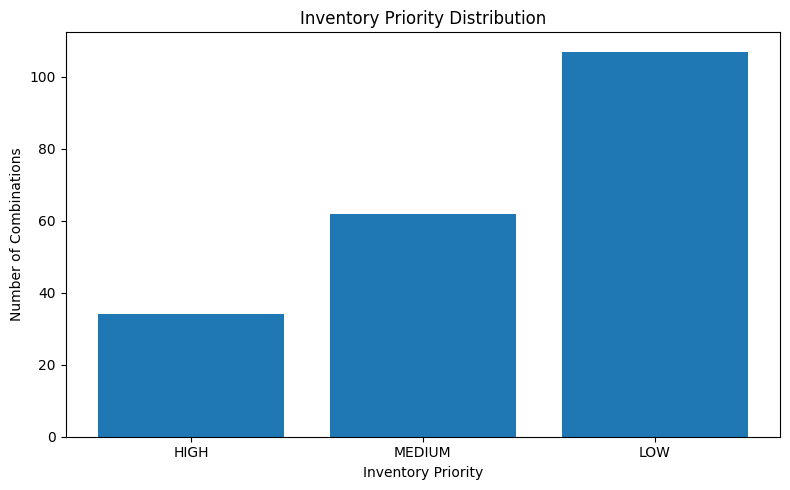


Inventory priority chart generated successfully.


In [9]:
# ============================================================
# CELL 8 — INVENTORY PRIORITY DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

print("=" * 75)
print("INVENTORY PRIORITY DISTRIBUTION")
print("=" * 75)

# Prepare priority data
priority_chart = priority_summary.copy()

# Keep logical priority order
priority_order = ["HIGH", "MEDIUM", "LOW"]

priority_chart["inventory_priority"] = pd.Categorical(
    priority_chart["inventory_priority"],
    categories=priority_order,
    ordered=True
)

priority_chart = priority_chart.sort_values("inventory_priority")

# Display summary
print(
    priority_chart[
        [
            "inventory_priority",
            "count",
            "total_forecast_demand",
            "total_safety_stock",
            "total_recommended_inventory"
        ]
    ].to_string(index=False)
)

# Create chart
plt.figure(figsize=(8, 5))

plt.bar(
    priority_chart["inventory_priority"].astype(str),
    priority_chart["count"]
)

plt.xlabel("Inventory Priority")
plt.ylabel("Number of Combinations")
plt.title("Inventory Priority Distribution")

plt.tight_layout()
plt.show()

print("\nInventory priority chart generated successfully.")

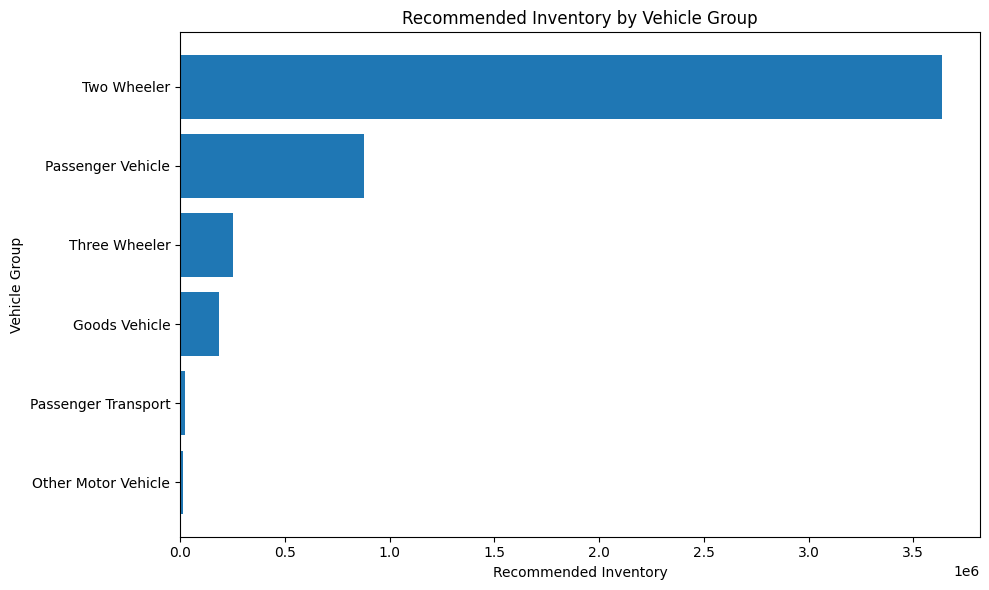

In [10]:
# ============================================================
# AUTO SUPPLY AI — INVENTORY REQUIREMENT ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# Sort vehicle groups by recommended inventory
inventory_plot = vehicle_kpi.sort_values(
    "total_recommended_inventory",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    inventory_plot["vehicle_group"],
    inventory_plot["total_recommended_inventory"]
)

plt.title("Recommended Inventory by Vehicle Group")
plt.xlabel("Recommended Inventory")
plt.ylabel("Vehicle Group")

plt.tight_layout()
plt.show()

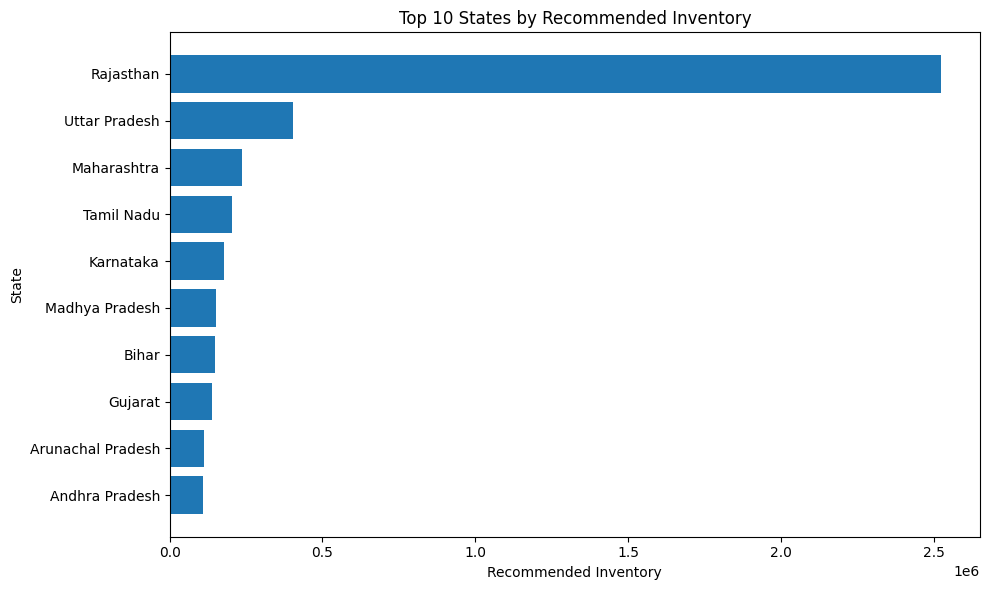

In [11]:
# ============================================================
# AUTO SUPPLY AI — STATE INVENTORY REQUIREMENT
# ============================================================

import matplotlib.pyplot as plt

# Sort states by recommended inventory
state_inventory_plot = state_kpi.sort_values(
    "total_recommended_inventory",
    ascending=True
).tail(10)

plt.figure(figsize=(10, 6))

plt.barh(
    state_inventory_plot["state"],
    state_inventory_plot["total_recommended_inventory"]
)

plt.title("Top 10 States by Recommended Inventory")
plt.xlabel("Recommended Inventory")
plt.ylabel("State")

plt.tight_layout()
plt.show()

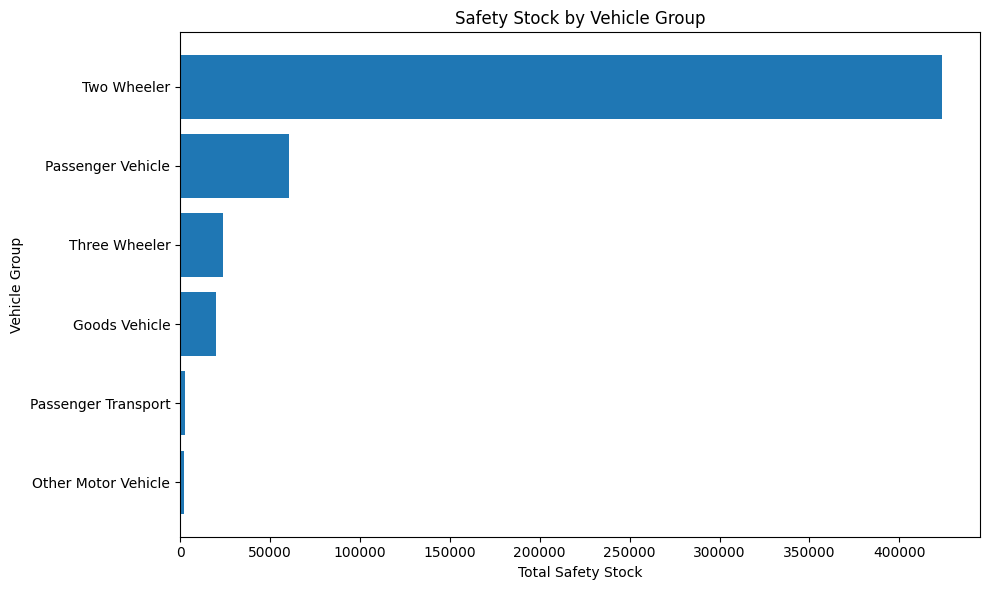

In [12]:
# ============================================================
# AUTO SUPPLY AI — SAFETY STOCK ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# Sort vehicle groups by safety stock
safety_stock_plot = vehicle_kpi.sort_values(
    "total_safety_stock",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    safety_stock_plot["vehicle_group"],
    safety_stock_plot["total_safety_stock"]
)

plt.title("Safety Stock by Vehicle Group")
plt.xlabel("Total Safety Stock")
plt.ylabel("Vehicle Group")

plt.tight_layout()
plt.show()

Inventory Priority Distribution
--------------------------------
inventory_priority
HIGH       34
MEDIUM     62
LOW       107
Name: count, dtype: int64


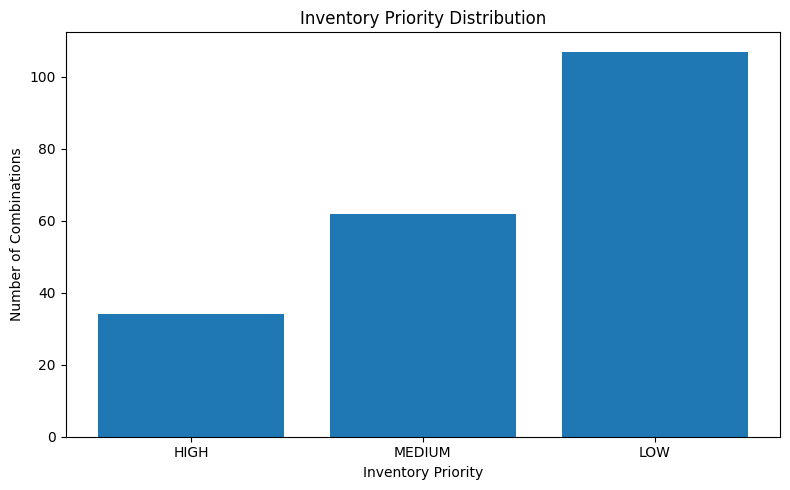

In [14]:
# ============================================================
# AUTO SUPPLY AI — INVENTORY PRIORITY DISTRIBUTION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load inventory data directly for this notebook
inventory_df = pd.read_csv("inventory_optimization.csv")

# Count combinations by inventory priority
priority_counts = (
    inventory_df["inventory_priority"]
    .value_counts()
    .reindex(["HIGH", "MEDIUM", "LOW"], fill_value=0)
)

# Display counts
print("Inventory Priority Distribution")
print("--------------------------------")
print(priority_counts)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    priority_counts.index,
    priority_counts.values
)

plt.title("Inventory Priority Distribution")
plt.xlabel("Inventory Priority")
plt.ylabel("Number of Combinations")

plt.tight_layout()
plt.show()

INVENTORY REQUIREMENT COMPARISON
      vehicle_group  total_recommended_inventory  total_safety_stock
        Two Wheeler                   3636367.62           423626.62
  Passenger Vehicle                    878940.57            60668.46
      Three Wheeler                    254308.84            23815.99
      Goods Vehicle                    186489.06            20130.24
Passenger Transport                     23808.36             2709.10
Other Motor Vehicle                     13445.33             2325.31


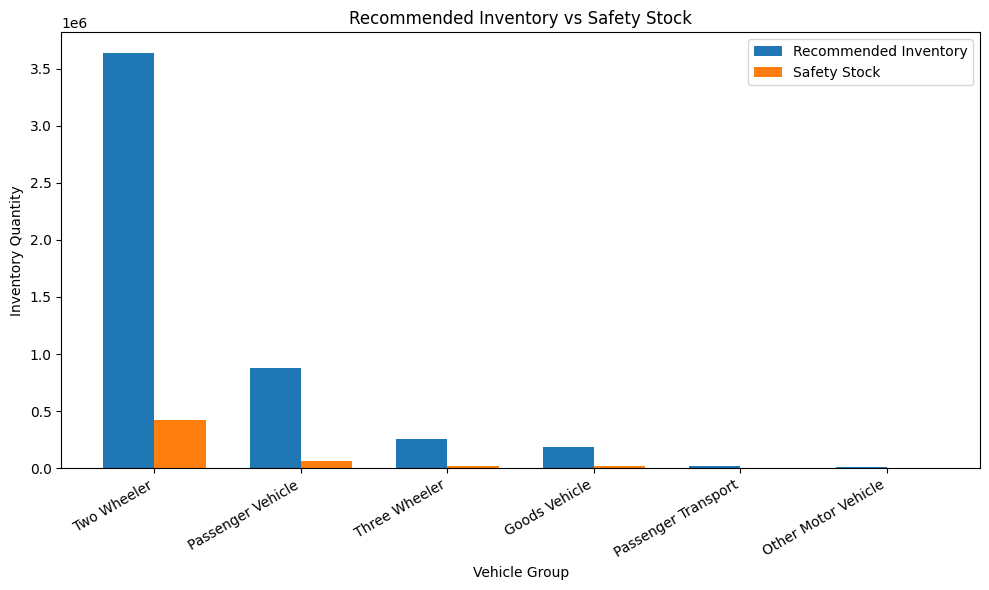

In [15]:
# ============================================================
# AUTO SUPPLY AI — INVENTORY REQUIREMENT COMPARISON
# ============================================================

# Aggregate inventory metrics by vehicle group
inventory_comparison = (
    inventory_df
    .groupby("vehicle_group", as_index=False)
    .agg(
        total_recommended_inventory=("recommended_inventory", "sum"),
        total_safety_stock=("safety_stock", "sum")
    )
    .sort_values(
        "total_recommended_inventory",
        ascending=False
    )
)

print("INVENTORY REQUIREMENT COMPARISON")
print("=" * 70)
print(inventory_comparison.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))

x = range(len(inventory_comparison))
width = 0.35

plt.bar(
    [i - width / 2 for i in x],
    inventory_comparison["total_recommended_inventory"],
    width=width,
    label="Recommended Inventory"
)

plt.bar(
    [i + width / 2 for i in x],
    inventory_comparison["total_safety_stock"],
    width=width,
    label="Safety Stock"
)

plt.xticks(
    list(x),
    inventory_comparison["vehicle_group"],
    rotation=30,
    ha="right"
)

plt.title("Recommended Inventory vs Safety Stock")
plt.xlabel("Vehicle Group")
plt.ylabel("Inventory Quantity")
plt.legend()

plt.tight_layout()
plt.show()

TOP 10 STATE × VEHICLE BY RECOMMENDED INVENTORY
         state     vehicle_group  recommended_inventory  safety_stock  total_forecast_demand
     Rajasthan       Two Wheeler             1819885.91     242194.66             9466147.50
     Rajasthan Passenger Vehicle              437441.15      16987.44             2522722.25
 Uttar Pradesh       Two Wheeler              306137.36      16524.93             1737674.53
   Maharashtra       Two Wheeler              167536.77      19191.09              890074.08
    Tamil Nadu       Two Wheeler              162849.19      19242.28              861641.46
     Rajasthan     Three Wheeler              145279.23      17116.60              768975.80
     Karnataka       Two Wheeler              130811.64      14806.87              696028.61
         Bihar       Two Wheeler              126551.32      22696.43              623129.37
Madhya Pradesh       Two Wheeler              113379.93      19306.01              564443.55
     Rajasthan     Goo

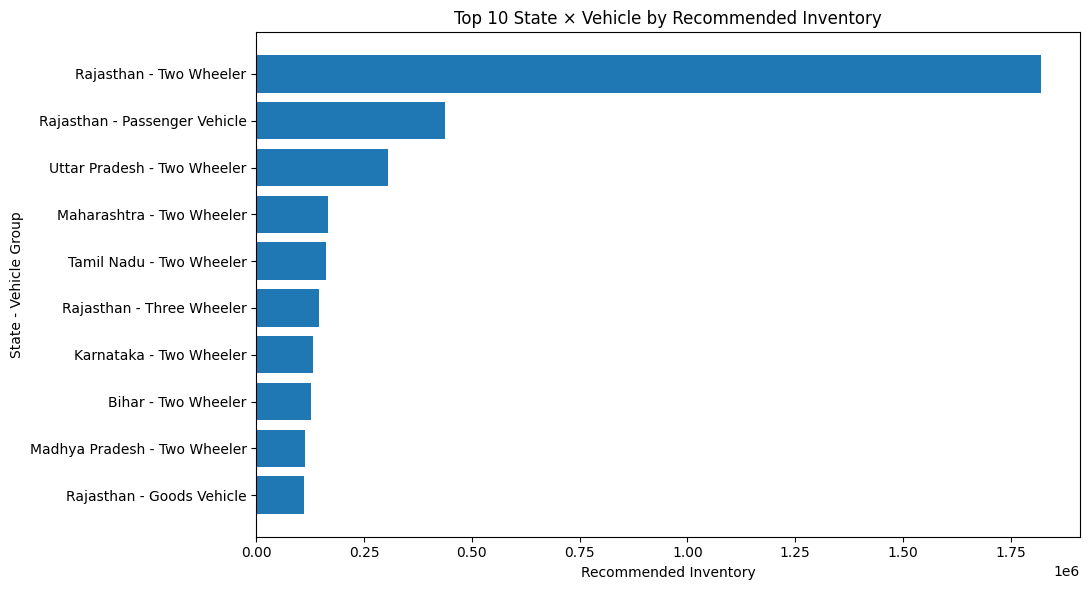

In [16]:
# ============================================================
# AUTO SUPPLY AI — TOP 10 STATE × VEHICLE BY INVENTORY
# ============================================================

top_inventory_combinations = (
    inventory_df[
        [
            "state",
            "vehicle_group",
            "recommended_inventory",
            "safety_stock",
            "total_forecast_demand"
        ]
    ]
    .sort_values(
        "recommended_inventory",
        ascending=False
    )
    .head(10)
    .copy()
)

print("TOP 10 STATE × VEHICLE BY RECOMMENDED INVENTORY")
print("=" * 80)
print(top_inventory_combinations.to_string(index=False))

# Create readable labels
top_inventory_combinations["state_vehicle"] = (
    top_inventory_combinations["state"]
    + " - "
    + top_inventory_combinations["vehicle_group"]
)

# Plot
plt.figure(figsize=(11, 6))

plt.barh(
    top_inventory_combinations["state_vehicle"][::-1],
    top_inventory_combinations["recommended_inventory"][::-1]
)

plt.title("Top 10 State × Vehicle by Recommended Inventory")
plt.xlabel("Recommended Inventory")
plt.ylabel("State - Vehicle Group")

plt.tight_layout()
plt.show()

INVENTORY COVERAGE BY VEHICLE GROUP
      vehicle_group  total_forecast_demand  total_recommended_inventory  inventory_coverage_percent
Other Motor Vehicle               66719.73                     13445.33                   20.151955
        Two Wheeler            19276446.02                   3636367.62                   18.864305
Passenger Transport              126595.29                     23808.36                   18.806671
      Goods Vehicle              998152.57                    186489.06                   18.683422
      Three Wheeler             1382956.89                    254308.84                   18.388776
  Passenger Vehicle             4909632.48                    878940.57                   17.902370


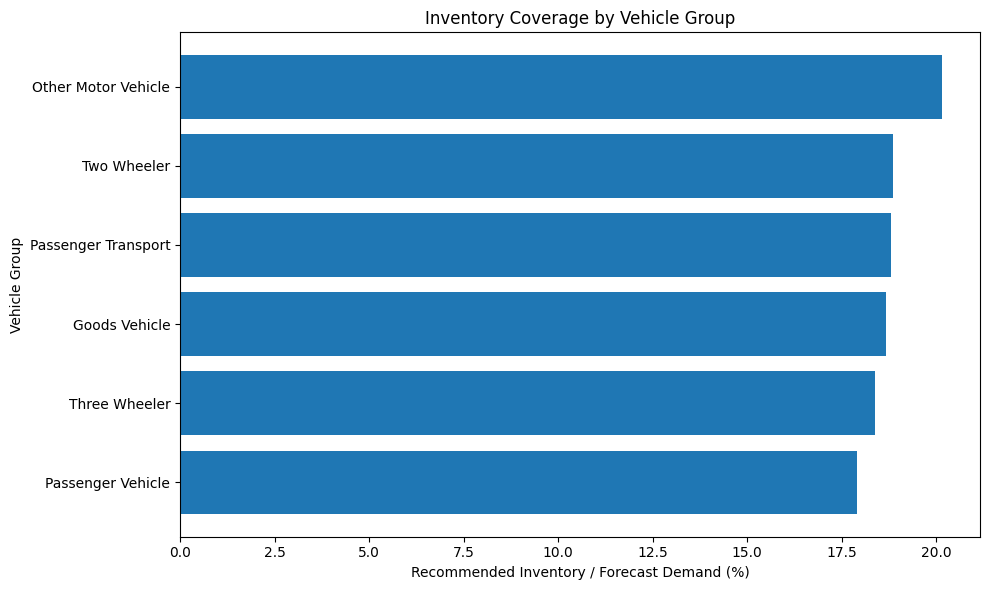

In [17]:
# ============================================================
# AUTO SUPPLY AI — INVENTORY COVERAGE ANALYSIS
# ============================================================

# Calculate inventory coverage
inventory_coverage = (
    inventory_df
    .groupby("vehicle_group", as_index=False)
    .agg(
        total_forecast_demand=("total_forecast_demand", "sum"),
        total_recommended_inventory=("recommended_inventory", "sum")
    )
)

inventory_coverage["inventory_coverage_percent"] = (
    inventory_coverage["total_recommended_inventory"]
    / inventory_coverage["total_forecast_demand"]
    * 100
)

inventory_coverage = inventory_coverage.sort_values(
    "inventory_coverage_percent",
    ascending=False
)

print("INVENTORY COVERAGE BY VEHICLE GROUP")
print("=" * 70)
print(inventory_coverage.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    inventory_coverage["vehicle_group"][::-1],
    inventory_coverage["inventory_coverage_percent"][::-1]
)

plt.title("Inventory Coverage by Vehicle Group")
plt.xlabel("Recommended Inventory / Forecast Demand (%)")
plt.ylabel("Vehicle Group")

plt.tight_layout()
plt.show()

TOP 10 STATES BY INVENTORY COVERAGE
                                       state  total_forecast_demand  total_recommended_inventory  inventory_coverage_percent
The Dadra And Nagar Haveli And Daman And Diu               13283.57                      2846.37                   21.427749
                                      Ladakh               10870.90                      2290.13                   21.066609
                                      Sikkim               16743.47                      3448.51                   20.596149
                                     Manipur               20299.89                      4139.09                   20.389716
                                       Bihar              755540.35                    149066.12                   19.729736
                              Madhya Pradesh              767727.89                    151175.82                   19.691328
                 Andaman And Nicobar Islands               22515.31                      

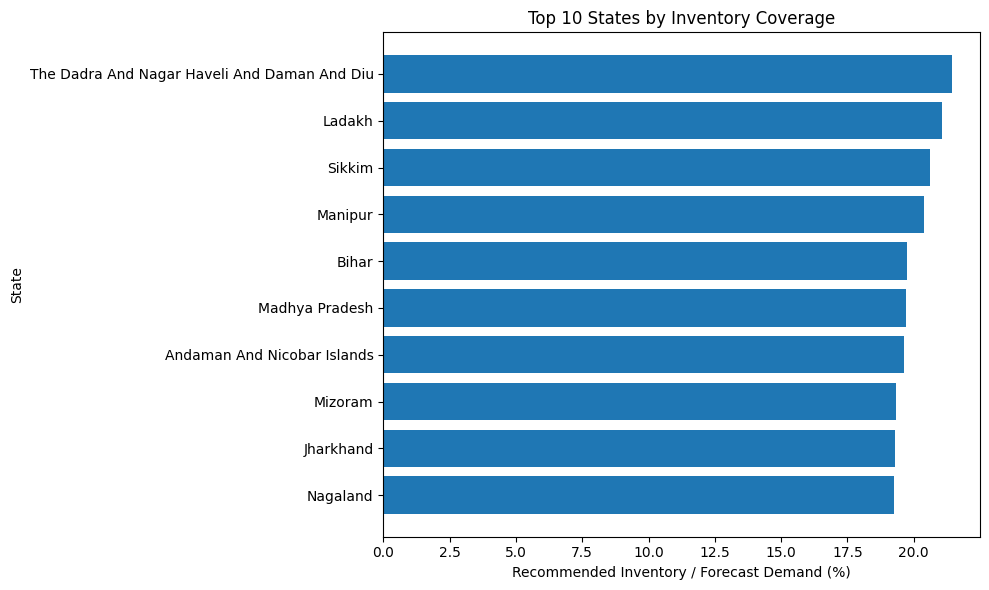

In [18]:
# ============================================================
# AUTO SUPPLY AI — STATE INVENTORY COVERAGE
# ============================================================

state_inventory_coverage = (
    inventory_df
    .groupby("state", as_index=False)
    .agg(
        total_forecast_demand=("total_forecast_demand", "sum"),
        total_recommended_inventory=("recommended_inventory", "sum")
    )
)

state_inventory_coverage["inventory_coverage_percent"] = (
    state_inventory_coverage["total_recommended_inventory"]
    / state_inventory_coverage["total_forecast_demand"]
    * 100
)

# Top 10 states by inventory coverage
top_state_coverage = (
    state_inventory_coverage
    .sort_values(
        "inventory_coverage_percent",
        ascending=False
    )
    .head(10)
)

print("TOP 10 STATES BY INVENTORY COVERAGE")
print("=" * 70)
print(top_state_coverage.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_state_coverage["state"][::-1],
    top_state_coverage["inventory_coverage_percent"][::-1]
)

plt.title("Top 10 States by Inventory Coverage")
plt.xlabel("Recommended Inventory / Forecast Demand (%)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# AUTO SUPPLY AI — OVERALL INVENTORY SUMMARY
# ============================================================

total_forecast = inventory_df["total_forecast_demand"].sum()
total_safety_stock = inventory_df["safety_stock"].sum()
total_recommended = inventory_df["recommended_inventory"].sum()

safety_stock_percent = (
    total_safety_stock / total_forecast * 100
)

recommended_inventory_percent = (
    total_recommended / total_forecast * 100
)

inventory_summary = pd.DataFrame({
    "Metric": [
        "Total Forecast Demand",
        "Total Safety Stock",
        "Recommended Inventory",
        "Safety Stock % of Forecast",
        "Recommended Inventory % of Forecast"
    ],
    "Value": [
        total_forecast,
        total_safety_stock,
        total_recommended,
        safety_stock_percent,
        recommended_inventory_percent
    ]
})

print("OVERALL INVENTORY SUMMARY")
print("=" * 70)

for _, row in inventory_summary.iterrows():
    if "%" in row["Metric"]:
        print(f"{row['Metric']:<40}: {row['Value']:.2f}%")
    else:
        print(f"{row['Metric']:<40}: {row['Value']:,.2f}")

print("=" * 70)
print("INVENTORY SUMMARY COMPLETE")

OVERALL INVENTORY SUMMARY
Total Forecast Demand                   : 26,760,502.98
Total Safety Stock                      : 533,275.72
Recommended Inventory                   : 4,993,359.78
Safety Stock % of Forecast              : 1.99%
Recommended Inventory % of Forecast     : 18.66%
INVENTORY SUMMARY COMPLETE
